# **Capítulo 3: IA para localización de Interferencias y Filtrado Espectral**

```
 Libro:  Procesamiento Digital de Voz e Imágenes en la Era de la Inteligencia Artificial
```


**Autor:  Dora María Ballesteros Larrotta**  
Universidad Militar Nueva Granada (UMNG)

---

### Material complementario del libro

Este notebook acompaña el **Capítulo 3** y contiene los ejemplos desarrollados a lo largo del texto. Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.


# **Ejemplo 18.  Algoritmo K-means aplicado al filtrado de ruido tonal presente en señal de voz**

Centroides encontrados:
Grupo 0: -97.68 dB
Grupo 1: -72.60 dB
Grupo seleccionado como ruido: 1


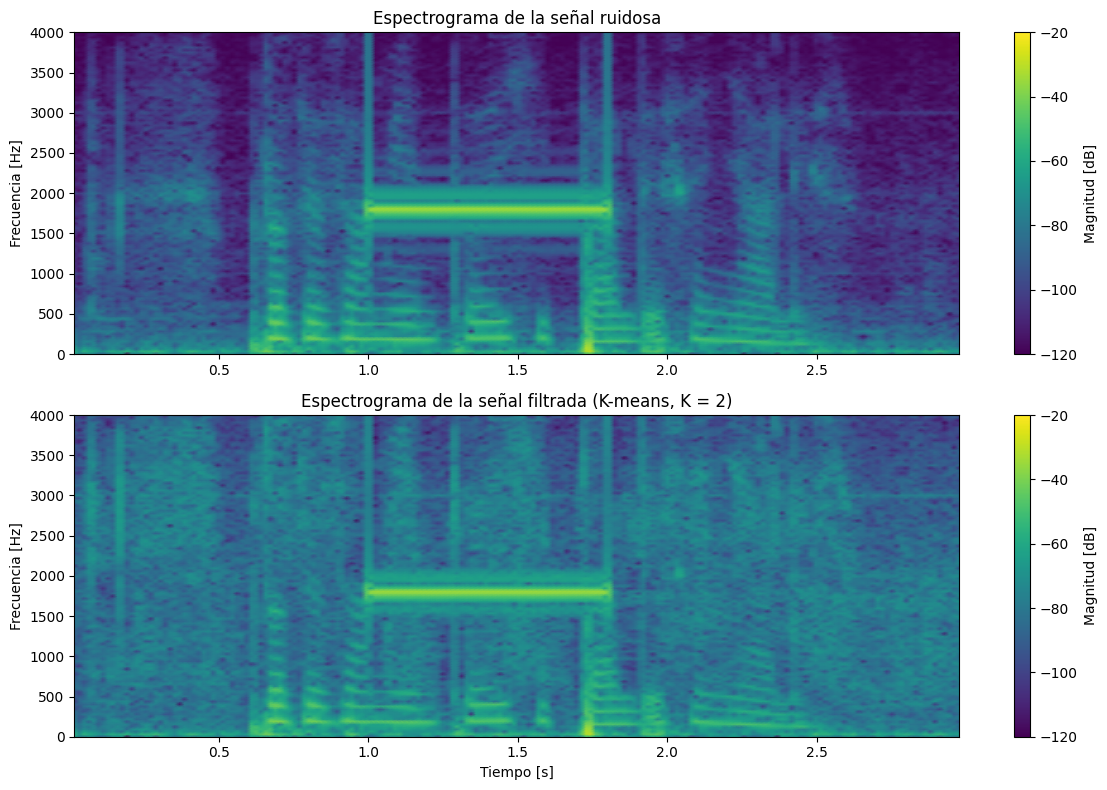

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import stft, istft, spectrogram
from sklearn.cluster import KMeans

x, fs = sf.read("audio_noisy.wav")
f, t, Zxx = stft(x, fs=fs, window="hann", nperseg=1024, noverlap=768)
S = np.abs(Zxx)
S_db = 20*np.log10(S + 1e-12)
X = S_db.reshape(-1, 1)

K = 2
kmeans = KMeans(n_clusters=K, random_state=0, n_init=10)
labels = kmeans.fit_predict(X)
labels_2D = labels.reshape(S_db.shape)

centros = kmeans.cluster_centers_.flatten()
cluster_ruido = np.argmax(centros)

print("Centroides encontrados:")
for i, c in enumerate(centros):
    print(f"Grupo {i}: {c:.2f} dB")
print(f"Grupo seleccionado como ruido: {cluster_ruido}")

mascara = np.ones_like(S)
mascara[labels_2D == cluster_ruido] = 0.05
Zxx_filtrado = Zxx * mascara
_, x_filtrada_kmeans = istft(Zxx_filtrado, fs=fs, window="hann",
                             nperseg=1024, noverlap=768)
x_filtrada_kmeans = x_filtrada_kmeans[:len(x)]
x_filtrada_kmeans = x_filtrada_kmeans / np.max(np.abs(x_filtrada_kmeans))

f1, t1, Sxx1 = spectrogram(x, fs=fs, nperseg=256, noverlap=128)
f2, t2, Sxx2 = spectrogram(x_filtrada_kmeans, fs=fs, nperseg=256, noverlap=128)
vmin, vmax = -120, -20
fig, ax = plt.subplots(2, 1, figsize=(12, 8))
im1 = ax[0].pcolormesh(t1, f1, 10*np.log10(Sxx1 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[0].set_title('Espectrograma de la señal ruidosa')
ax[0].set_ylabel('Frecuencia [Hz]')
ax[0].set_ylim([0, 4000])
cbar1 = fig.colorbar(im1, ax=ax[0])
cbar1.set_label('Magnitud [dB]')

im2 = ax[1].pcolormesh(t2, f2, 10*np.log10(Sxx2 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[1].set_title('Espectrograma de la señal filtrada (K-means, K = 2)')
ax[1].set_xlabel('Tiempo [s]')
ax[1].set_ylabel('Frecuencia [Hz]')
ax[1].set_ylim([0, 4000])
cbar2 = fig.colorbar(im2, ax=ax[1])
cbar2.set_label('Magnitud [dB]')

plt.tight_layout()
plt.show()

sf.write("audio_filtrado_kmeans.wav", x_filtrada_kmeans, fs)

# **Ejemplo 19.  Algoritmo DBSCAN aplicado al filtrado de ruido tonal presente en señal de voz**

Grupos encontrados: [-1  0]
Frecuencia interferente estimada: 1796.88 Hz
Frecuencia interferente estimada: 1796.88 Hz


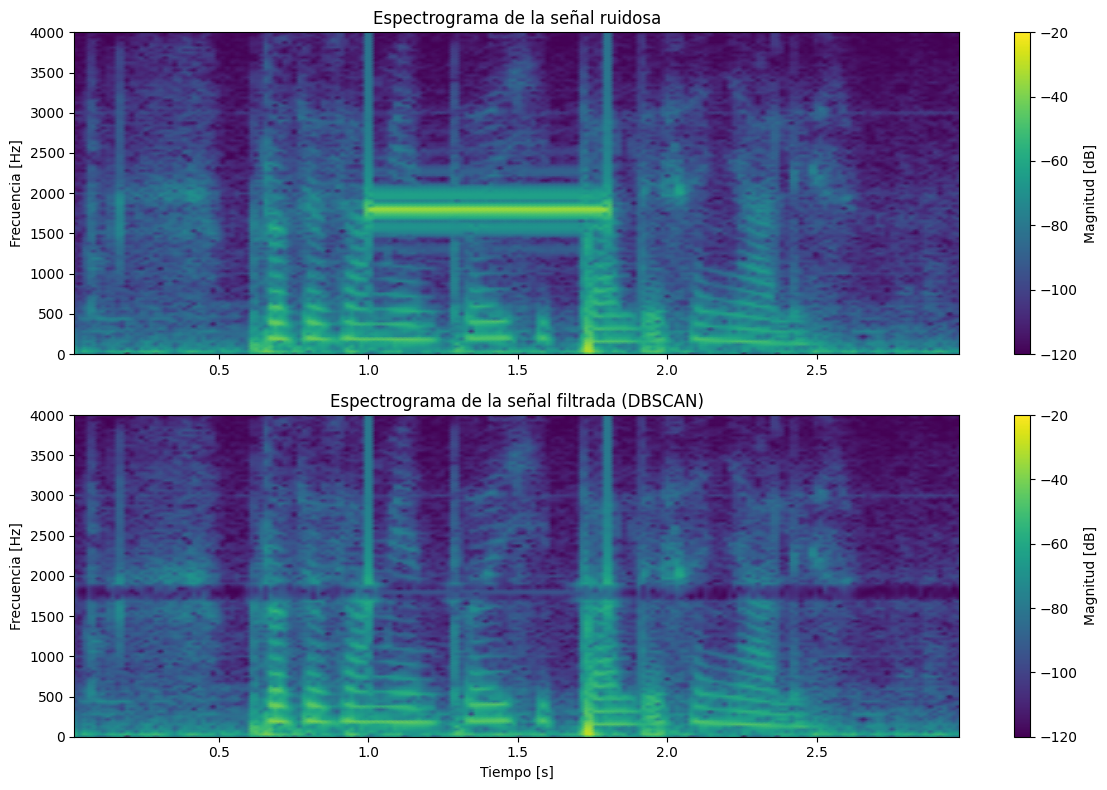

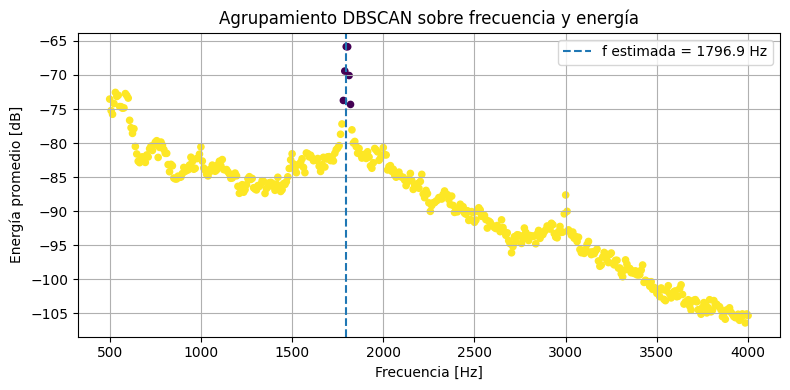

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy.signal import stft, istft, spectrogram
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

x, fs = sf.read("audio_noisy.wav")
f, t, Zxx = stft(x, fs=fs, window="hann", nperseg=1024, noverlap=768)
S = np.abs(Zxx)
S_db = 20*np.log10(S + 1e-12)

# Perfil promedio de energía por frecuencia
perfil_frecuencia = np.mean(S_db, axis=1)

# Analizar solo una banda donde puede estar el tono
idx_busqueda = (f >= 500) & (f <= 4000)

f_roi = f[idx_busqueda]
E_roi = perfil_frecuencia[idx_busqueda]

# Datos para DBSCAN: frecuencia + energía
X = np.column_stack((f_roi, E_roi))
X_scaled = StandardScaler().fit_transform(X)

# DBSCAN
dbscan = DBSCAN(eps=0.30, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

print("Grupos encontrados:", np.unique(labels))

# Identificar grupo candidato a ruido:
# tomamos el grupo con mayor energía promedio, excluyendo etiqueta -1
grupos = np.unique(labels)
grupos_validos = grupos[grupos != -1]

if len(grupos_validos) > 0:
    energia_grupos = []
    for g in grupos_validos:
        energia_grupos.append(np.mean(E_roi[labels == g]))

    grupo_ruido = grupos_validos[np.argmax(energia_grupos)]
    idx_grupo_ruido = labels == grupo_ruido
    idx_max = np.argmax(E_roi)
    f_ruido = f_roi[idx_max]
    print(f"Frecuencia interferente estimada: {f_ruido:.2f} Hz")

else:
    print("No se encontraron grupos válidos para el ruido.")

print(f"Frecuencia interferente estimada: {f_ruido:.2f} Hz")

# Máscara tipo notch guiada por DBSCAN
#ancho_banda = 80
ancho_banda = 100
#atenuacion = 0.005
atenuacion = 0.001

mascara = np.ones_like(S)

idx_ruido = (f >= f_ruido - ancho_banda) & (f <= f_ruido + ancho_banda)
mascara[idx_ruido, :] = atenuacion

Zxx_filtrado = Zxx * mascara

_, x_filtrada_dbscan = istft(Zxx_filtrado, fs=fs, window="hann",
                             nperseg=1024, noverlap=768)

x_filtrada_dbscan = x_filtrada_dbscan[:len(x)]
x_filtrada_dbscan = x_filtrada_dbscan / np.max(np.abs(x_filtrada_dbscan))

sf.write("audio_filtrado_dbscan.wav", x_filtrada_dbscan, fs)

# Espectrogramas
f1, t1, Sxx1 = spectrogram(x, fs=fs, nperseg=256, noverlap=128)
f2, t2, Sxx2 = spectrogram(x_filtrada_dbscan, fs=fs, nperseg=256, noverlap=128)

vmin, vmax = -120, -20

fig, ax = plt.subplots(2, 1, figsize=(12, 8))

im1 = ax[0].pcolormesh(t1, f1, 10*np.log10(Sxx1 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[0].set_title('Espectrograma de la señal ruidosa')
ax[0].set_ylabel('Frecuencia [Hz]')
ax[0].set_ylim([0, 4000])
cbar1 = fig.colorbar(im1, ax=ax[0])
cbar1.set_label('Magnitud [dB]')

im2 = ax[1].pcolormesh(t2, f2, 10*np.log10(Sxx2 + 1e-12),
                       shading='gouraud', vmin=vmin, vmax=vmax)
ax[1].set_title('Espectrograma de la señal filtrada (DBSCAN)')
ax[1].set_xlabel('Tiempo [s]')
ax[1].set_ylabel('Frecuencia [Hz]')
ax[1].set_ylim([0, 4000])
cbar2 = fig.colorbar(im2, ax=ax[1])
cbar2.set_label('Magnitud [dB]')

plt.tight_layout()
plt.show()

# Visualización de DBSCAN
plt.figure(figsize=(8, 4))
plt.scatter(f_roi, E_roi, c=labels, s=20)
plt.axvline(f_ruido, linestyle='--', label=f'f estimada = {f_ruido:.1f} Hz')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Energía promedio [dB]')
plt.title('Agrupamiento DBSCAN sobre frecuencia y energía')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from IPython.display import Audio, display

print("Audio filtrado:")
display(Audio(x_filtrada_dbscan, rate=fs)) # play audio filtrado

Audio filtrado:


# **Ejemplo 20.  Comparación cuantitativa de filtrado de voz con ruido tonal utilizando filtros FIR, IIR y máscara con localización de tono con IA**

**Resultados con K-means y DBSCAN**

In [ ]:
import librosa
import numpy as np
from scipy.signal import spectrogram

def energia_residual_tono(x, fs, f_tono=1800, ancho_banda=50):
    """
    Calcula la energía residual alrededor de un tono interferente
    usando el espectrograma de la señal.

    Parámetros:
    x : señal de audio
    fs : frecuencia de muestreo
    f_tono : frecuencia del tono interferente
    ancho_banda : ancho a cada lado de la frecuencia central

    Retorna:
    energia_tono : energía acumulada en la banda del tono
    """

    f, t, Sxx = spectrogram(x, fs=fs, nperseg=512, noverlap=256)
    f_min = f_tono - ancho_banda
    f_max = f_tono + ancho_banda
    idx_banda = (f >= f_min) & (f <= f_max)
    energia_tono = np.sum(Sxx[idx_banda, :])
    return energia_tono

y_kmeans, fs = librosa.load("audio_filtrado_kmeans.wav", sr=None)
y_dbscan, fs = librosa.load("audio_filtrado_dbscan.wav", sr=None)

E_kmeans = energia_residual_tono(y_kmeans, fs)
E_dbscan = energia_residual_tono(y_dbscan, fs)

print("Energía residual del tono de 1800 Hz")
print(f"Filtrado con K-means: {E_kmeans:.6e}")
print(f"Filtrado con DBSCAN: {E_dbscan:.6e}")


Energía residual del tono de 1800 Hz
Filtrado con K-means: 2.574687e-02
Filtrado con DBSCAN: 1.184714e-07


In [ ]:
import numpy as np
from scipy.signal import spectrogram

def energia_banda_voz(x, fs, f_min=0, f_max=1200):
    """
    Calcula la energía conservada en la banda útil de la voz
    a partir del espectrograma de la señal.

    Parámetros:
    x : señal de audio
    fs : frecuencia de muestreo
    f_min : frecuencia mínima de la banda útil
    f_max : frecuencia máxima de la banda útil

    Retorna:
    energia_voz : energía acumulada en la banda de voz
    """

    f, t, Sxx = spectrogram(x, fs=fs, nperseg=512, noverlap=256)
    idx_banda = (f >= f_min) & (f <= f_max)
    energia_voz = np.sum(Sxx[idx_banda, :])
    return energia_voz

y_kmeans, fs = librosa.load("audio_filtrado_kmeans.wav", sr=None)
y_dbscan, fs = librosa.load("audio_filtrado_dbscan.wav", sr=None)

Evoz_kmeans = energia_banda_voz(y_kmeans, fs)
Evoz_dbscan = energia_banda_voz(y_dbscan, fs)


print("Energía conservada en la banda útil de la voz")
print(f"Filtrado con K-means: {Evoz_kmeans:.6e}")
print(f"Filtrado con DBSCAN: {Evoz_dbscan:.6e}")

Energía conservada en la banda útil de la voz
Filtrado con K-means: 8.688575e-03
Filtrado con DBSCAN: 1.262381e-02


In [ ]:
R_dbscan = E_dbscan / Evoz_dbscan
print (R_dbscan)

9.384757e-06
